<a href="https://colab.research.google.com/github/gautham-c/tmdb-ios/blob/master/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [329]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score

In [207]:
df = pd.read_csv('car.csv')
df.head()

,vehicle_id,vehicle_type,manufacturer,region,fuel_type,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,tire_condition,maintenance_cost_usd,breakdown_next_30_days
0,VH-13687,Van,Hyundai,Central,DIESEL,2012-12-04,02/20/2025,12.5,219266.0,4763.0,16.5,10,4.0,Good,7088.55,1
1,VH-13098,Truck,Toyota,Central,Gasoline,2015-08-16,01/22/2025,9.8,115261.0,2737.0,25.9,2,2.6,Good,3745.02,False
2,VH-13739,Sedan,Hyundai,West,Diesel,02/14/2018,"February 20, 2025",7.3,149791.0,3447.0,12.3,3,2.1,Good,3011.11,No
3,VH-13366,Van,Nissan,Central,hybrid,2024-12-01,07-04-2025,0.5,4075.0,200.0,NaN,0,NaN,Good,673.45,0
4,VH-15413,truck,Mercedes,South,Diesel,06/02/2023,09/24/2024,2.0,16074.0,432.0,25.1,3,3.1,GOOD,2086.91,0


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6120 entries, 0 to 6119
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   vehicle_id                    6120 non-null   object
 1   vehicle_type                  6120 non-null   object
 2   manufacturer                  5970 non-null   object
 3   region                        6120 non-null   object
 4   fuel_type                     6120 non-null   object
 5   purchase_date                 6120 non-null   object
 6   last_service_date             5747 non-null   object
 7   vehicle_age_years             5870 non-null   object
 8   mileage_km                    5919 non-null   object
 9   engine_hours                  5659 non-null   object
 10  avg_fuel_consumption_l_100km  5764 non-null   object
 11  num_repairs_last_year         6120 non-null   int64 
 12  driver_rating                 5573 non-null   object
 13  tire_condition    

In [209]:
df.describe()

,num_repairs_last_year
count,6120.000000
mean,2.568137
std,2.184555
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,18.000000


In [210]:
df.duplicated().sum()

np.int64(120)

In [211]:
df.drop_duplicates(inplace=True)

In [212]:
df['vehicle_type'].unique()

array(['Van', 'Truck', 'Sedan', 'truck', 'sedan', 'SUV', 'suv', 'van',
       'VAN', 'Bus', 'TRUCK', 'BUS', 'bus', 'SEDAN'], dtype=object)

In [213]:
df['vehicle_type'] = df['vehicle_type'].str.capitalize().astype(str)

In [214]:
df['manufacturer'].unique()

array(['Hyundai', 'Toyota', 'Nissan', 'Mercedes', 'Volvo', 'Ford', nan,
       '?'], dtype=object)

In [215]:
df['manufacturer'].replace('?',np.nan, inplace=True)

/tmp/ipykernel_5254/4198688926.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['manufacturer'].replace('?',np.nan, inplace=True)


In [216]:
df['manufacturer'].isna().sum()

np.int64(180)

In [217]:
df['region'].unique()

array(['Central', '  West ', 'South', 'East', 'West', 'North', '  East ',
       '  Central ', '  South ', '  North '], dtype=object)

In [218]:
df['region'] = df['region'].str.strip()

In [219]:
df['fuel_type'].unique()

array(['DIESEL', 'Gasoline', 'Diesel', 'hybrid', 'DSL', 'EV', 'Petrol',
       'Electric ', 'HYB', 'PETROL', 'Electric', 'Gas', 'petrol',
       'diesel', 'Hybrid', 'electric'], dtype=object)

In [220]:
df['fuel_type'] = df['fuel_type'].str.strip().str.capitalize()

In [221]:
df['fuel_type'] = df['fuel_type'].replace('Dsl','Diesel')
df['fuel_type'] = df['fuel_type'].replace('Gas','Gasoline')
df['fuel_type'] = df['fuel_type'].replace('Ev','Electric')
df['fuel_type'] = df['fuel_type'].replace('Hyb','Hybrid')

In [222]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'],format='mixed',errors='coerce')

In [223]:
df['last_service_date'] = pd.to_datetime(df['last_service_date'],format='mixed',errors='coerce')

In [224]:
df['last_service_date'].isna().sum()

np.int64(360)

In [225]:
df['vehicle_age_years'] = df['vehicle_age_years'].replace('?',np.nan)

In [226]:
df['vehicle_age_years'] = df['vehicle_age_years'].astype(float)

In [227]:
mask = df['mileage_km'] == '?'
df.loc[mask,'mileage_km'] = df.loc[mask,'mileage_km'].replace('?',np.nan)

/tmp/ipykernel_5254/2335245660.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[mask,'mileage_km'] = df.loc[mask,'mileage_km'].replace('?',np.nan)


In [228]:
df['mileage_km'] = df['mileage_km'].str.replace(',','').astype(float)

In [229]:
mask = df['engine_hours'] == '?'
df.loc[mask,'engine_hours'] = df.loc[mask,'engine_hours'].replace('?',np.nan)

/tmp/ipykernel_5254/95809801.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[mask,'engine_hours'] = df.loc[mask,'engine_hours'].replace('?',np.nan)


In [230]:
df['engine_hours'] = df['engine_hours'].str.replace(',','').astype(float)

In [231]:
df['avg_fuel_consumption_l_100km'] = df['avg_fuel_consumption_l_100km'].replace('?',np.nan)

In [232]:
df['avg_fuel_consumption_l_100km'] = df['avg_fuel_consumption_l_100km'].astype(float)

In [233]:
df['num_repairs_last_year'] = df['num_repairs_last_year'].astype(float)

In [234]:
df['tire_condition'] = df['tire_condition'].str.strip().str.capitalize()

In [235]:
df['tire_condition'].unique()

array(['Good', 'Poor', 'Fair'], dtype=object)

In [236]:
df['maintenance_cost_usd']= df['maintenance_cost_usd'].replace('?',np.nan)

In [237]:
df['maintenance_cost_usd'] = (
    df['maintenance_cost_usd']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

In [238]:
mask = pd.to_numeric(df['maintenance_cost_usd'],errors='coerce').isna()
df.loc[mask,'maintenance_cost_usd'] = df.loc[mask,'maintenance_cost_usd'].replace('unknown',np.nan)

/tmp/ipykernel_5254/3225191439.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[mask,'maintenance_cost_usd'] = df.loc[mask,'maintenance_cost_usd'].replace('unknown',np.nan)


In [239]:
df['maintenance_cost_usd']= df['maintenance_cost_usd'].astype(float)

In [240]:
df['breakdown_next_30_days'].unique()

array(['1', 'False', 'No', '0', 'Yes', 'True'], dtype=object)

In [241]:
df['breakdown_next_30_days'] = df['breakdown_next_30_days'].replace(['Yes','True'],1)
df['breakdown_next_30_days'] = df['breakdown_next_30_days'].replace(['No','False'],0)

In [242]:
df['breakdown_next_30_days'] = df['breakdown_next_30_days'].astype(bool)

In [243]:
df.head()

,vehicle_id,vehicle_type,manufacturer,region,fuel_type,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,tire_condition,maintenance_cost_usd,breakdown_next_30_days
0,VH-13687,Van,Hyundai,Central,Diesel,2012-12-04,2025-02-20,12.5,219266.0,4763.0,16.5,10.0,4.0,Good,7088.55,True
1,VH-13098,Truck,Toyota,Central,Gasoline,2015-08-16,2025-01-22,9.8,115261.0,2737.0,25.9,2.0,2.6,Good,3745.02,False
2,VH-13739,Sedan,Hyundai,West,Diesel,2018-02-14,2025-02-20,7.3,149791.0,3447.0,12.3,3.0,2.1,Good,3011.11,False
3,VH-13366,Van,Nissan,Central,Hybrid,2024-12-01,2025-07-04,0.5,4075.0,200.0,NaN,0.0,NaN,Good,673.45,True
4,VH-15413,Truck,Mercedes,South,Diesel,2023-06-02,2024-09-24,2.0,16074.0,432.0,25.1,3.0,3.1,Good,2086.91,True


In [244]:
df.isna().sum()

,0
vehicle_id,0
vehicle_type,0
manufacturer,180
region,0
fuel_type,0
purchase_date,0
last_service_date,360
vehicle_age_years,297
mileage_km,238
engine_hours,540


In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 0 to 6119
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   vehicle_id                    6000 non-null   object        
 1   vehicle_type                  6000 non-null   object        
 2   manufacturer                  5820 non-null   object        
 3   region                        6000 non-null   object        
 4   fuel_type                     6000 non-null   object        
 5   purchase_date                 6000 non-null   datetime64[ns]
 6   last_service_date             5640 non-null   datetime64[ns]
 7   vehicle_age_years             5703 non-null   float64       
 8   mileage_km                    5762 non-null   float64       
 9   engine_hours                  5460 non-null   float64       
 10  avg_fuel_consumption_l_100km  5580 non-null   float64       
 11  num_repairs_last_year         6000 

In [246]:
df.describe()

,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,maintenance_cost_usd
count,6000,5640,5703.000000,5.762000e+03,5460.000000,5580.000000,6000.000000,5880.000000
mean,2021-03-23 16:28:19.200000,2025-03-01 12:59:44.680851200,4.174838,1.160405e+05,1675.045238,16.970950,2.568667,2331.421900
min,2007-06-06 00:00:00,2022-12-21 00:00:00,0.000000,-1.000000e+00,10.000000,0.000000,0.000000,50.000000
25%,2019-10-28 00:00:00,2025-01-21 00:00:00,2.100000,3.600150e+04,790.750000,9.200000,1.000000,1323.162500
50%,2021-10-26 00:00:00,2025-03-28 00:00:00,3.500000,6.183350e+04,1395.000000,14.100000,2.000000,2047.685000
75%,2023-04-27 00:00:00,2025-05-08 00:00:00,5.600000,1.008198e+05,2267.250000,27.400000,4.000000,3048.127500
max,2025-12-02 00:00:00,2025-12-05 00:00:00,18.000000,9.999999e+06,9215.000000,41.600000,18.000000,12054.990000
std,NaN,NaN,2.817309,6.416805e+05,1238.969311,10.683674,2.188245,1401.470602


In [247]:
mask = df['mileage_km']<0
df.loc[mask,'mileage_km'] = np.nan

In [248]:
df['mileage_km'].fillna(df['mileage_km'].mean(),inplace=True)

/tmp/ipykernel_5254/205713313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mileage_km'].fillna(df['mileage_km'].mean(),inplace=True)


In [249]:
df['manufacturer'].fillna('unknown',inplace=True)

/tmp/ipykernel_5254/3436758228.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['manufacturer'].fillna('unknown',inplace=True)


In [251]:
df['driver_rating'] = pd.to_numeric(df['driver_rating'],errors='coerce')

,driver_rating
0,4.0
1,2.6
2,2.1
3,NaN
4,3.1
...,...
6114,4.3
6115,4.1
6117,3.6
6118,NaN


In [252]:
df['vehicle_age_years'].fillna(df['vehicle_age_years'].mean(),inplace=True)
df['engine_hours'].fillna(df['engine_hours'].mean(),inplace=True)
df['avg_fuel_consumption_l_100km'].fillna(df['avg_fuel_consumption_l_100km'].median(),inplace=True)
df['driver_rating'].fillna(df['driver_rating'].mean(),inplace=True)
df['maintenance_cost_usd'].fillna(df['maintenance_cost_usd'].median(),inplace=True)


/tmp/ipykernel_5254/4204878285.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['vehicle_age_years'].fillna(df['vehicle_age_years'].mean(),inplace=True)
/tmp/ipykernel_5254/4204878285.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 0 to 6119
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   vehicle_id                    6000 non-null   object        
 1   vehicle_type                  6000 non-null   object        
 2   manufacturer                  6000 non-null   object        
 3   region                        6000 non-null   object        
 4   fuel_type                     6000 non-null   object        
 5   purchase_date                 6000 non-null   datetime64[ns]
 6   last_service_date             5598 non-null   datetime64[ns]
 7   vehicle_age_years             6000 non-null   float64       
 8   mileage_km                    6000 non-null   float64       
 9   engine_hours                  6000 non-null   float64       
 10  avg_fuel_consumption_l_100km  6000 non-null   float64       
 11  num_repairs_last_year         6000 

In [254]:
df.loc[df['last_service_date'] < df['purchase_date'], 'last_service_date'] = pd.NaT

In [259]:
ref = df['last_service_date'].max()          # or a fixed pd.Timestamp('2025-06-01')
df['days_since_last_service'] = (ref - df['last_service_date']).dt.days
df['service_date_missing'] = df['last_service_date'].isna().astype(bool)

In [260]:
df.head()

,vehicle_id,vehicle_type,manufacturer,region,fuel_type,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,tire_condition,maintenance_cost_usd,breakdown_next_30_days,days_since_last_service,service_date_missing
0,VH-13687,Van,Hyundai,Central,Diesel,2012-12-04,2025-02-20,12.5,219266.0,4763.0,16.5,10.0,4.000000,Good,7088.55,True,288.0,False
1,VH-13098,Truck,Toyota,Central,Gasoline,2015-08-16,2025-01-22,9.8,115261.0,2737.0,25.9,2.0,2.600000,Good,3745.02,False,317.0,False
2,VH-13739,Sedan,Hyundai,West,Diesel,2018-02-14,2025-02-20,7.3,149791.0,3447.0,12.3,3.0,2.100000,Good,3011.11,False,288.0,False
3,VH-13366,Van,Nissan,Central,Hybrid,2024-12-01,2025-07-04,0.5,4075.0,200.0,14.1,0.0,4.111097,Good,673.45,True,154.0,False
4,VH-15413,Truck,Mercedes,South,Diesel,2023-06-02,2024-09-24,2.0,16074.0,432.0,25.1,3.0,3.100000,Good,2086.91,True,437.0,False


In [261]:
df.describe()

,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,maintenance_cost_usd,days_since_last_service
count,6000,5598,6000.000000,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,5598.000000
mean,2021-03-23 16:28:19.200000,2025-03-03 05:11:15.241157632,4.174838,1.172410e+05,1675.045238,16.769983,2.568667,4.111097,2325.747162,276.783851
min,2007-06-06 00:00:00,2022-12-21 00:00:00,0.000000,5.000000e+02,10.000000,0.000000,0.000000,1.000000,50.000000,0.000000
25%,2019-10-28 00:00:00,2025-01-23 00:00:00,2.200000,3.792650e+04,847.000000,9.700000,1.000000,3.100000,1337.015000,210.000000
50%,2021-10-26 00:00:00,2025-03-28 00:00:00,3.700000,6.561500e+04,1533.000000,14.100000,2.000000,3.700000,2047.685000,252.000000
75%,2023-04-27 00:00:00,2025-05-09 00:00:00,5.400000,1.108670e+05,2152.500000,26.900000,4.000000,4.111097,3027.125000,316.000000
max,2025-12-02 00:00:00,2025-12-05 00:00:00,18.000000,9.999999e+06,9215.000000,41.600000,18.000000,99.000000,12054.990000,1080.000000
std,NaN,NaN,2.746684,6.287165e+05,1181.891652,10.328910,2.188245,6.776115,1387.951403,101.779106


In [262]:
df['maintenance_cost_usd'].skew()

np.float64(1.3122495238088863)

In [264]:
df['maintenance_cost_usd'].mean()

np.float64(2325.7471616666667)

In [263]:
df['maintenance_cost_usd'].value_counts()

,count
maintenance_cost_usd,
2047.685,120
50.000,32
967.190,3
1436.820,2
2174.030,2
...,...
2087.420,1
8981.910,1
2956.410,1


<Axes: xlabel='maintenance_cost_usd', ylabel='Count'>

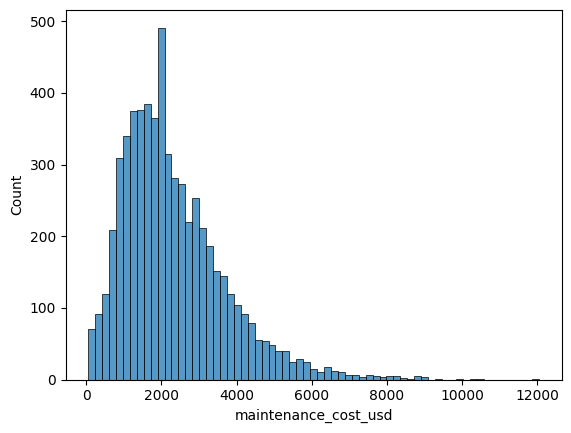

In [265]:
sns.histplot(data=df,x='maintenance_cost_usd')

<Axes: >

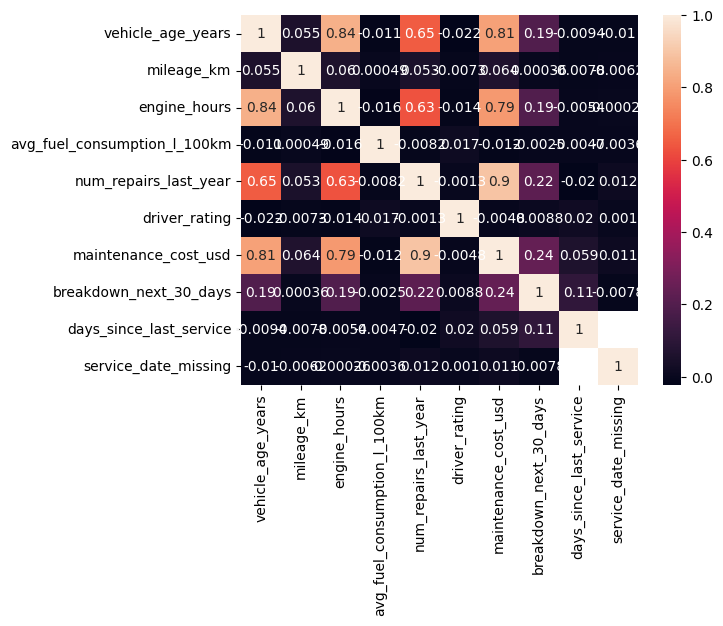

In [267]:
df.head()

,vehicle_id,vehicle_type,manufacturer,region,fuel_type,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,tire_condition,maintenance_cost_usd,breakdown_next_30_days,days_since_last_service,service_date_missing
0,VH-13687,Van,Hyundai,Central,Diesel,2012-12-04,2025-02-20,12.5,219266.0,4763.0,16.5,10.0,4.000000,Good,7088.55,True,288.0,False
1,VH-13098,Truck,Toyota,Central,Gasoline,2015-08-16,2025-01-22,9.8,115261.0,2737.0,25.9,2.0,2.600000,Good,3745.02,False,317.0,False
2,VH-13739,Sedan,Hyundai,West,Diesel,2018-02-14,2025-02-20,7.3,149791.0,3447.0,12.3,3.0,2.100000,Good,3011.11,False,288.0,False
3,VH-13366,Van,Nissan,Central,Hybrid,2024-12-01,2025-07-04,0.5,4075.0,200.0,14.1,0.0,4.111097,Good,673.45,True,154.0,False
4,VH-15413,Truck,Mercedes,South,Diesel,2023-06-02,2024-09-24,2.0,16074.0,432.0,25.1,3.0,3.100000,Good,2086.91,True,437.0,False


In [278]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [279]:
df.describe()

,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,maintenance_cost_usd,days_since_last_service
count,6000,5598,"6,000","6,000","6,000","6,000","6,000","6,000","6,000","5,598"
mean,2021-03-23 16:28:19.200000,2025-03-03 05:11:15.241157632,4,"117,241","1,675",17,3,4,"2,326",277
min,2007-06-06 00:00:00,2022-12-21 00:00:00,0,500,10,0,0,1,50,0
25%,2019-10-28 00:00:00,2025-01-23 00:00:00,2,"37,926",847,10,1,3,"1,337",210
50%,2021-10-26 00:00:00,2025-03-28 00:00:00,4,"65,615","1,533",14,2,4,"2,048",252
75%,2023-04-27 00:00:00,2025-05-09 00:00:00,5,"110,867","2,152",27,4,4,"3,027",316
max,2025-12-02 00:00:00,2025-12-05 00:00:00,18,"9,999,999","9,215",42,18,99,"12,055","1,080"
std,NaN,NaN,3,"628,717","1,182",10,2,7,"1,388",102


In [273]:
df.groupby('manufacturer')['maintenance_cost_usd'].agg(['mean', 'count']).sort_values(by='count',ascending=False)

,mean,count
manufacturer,,
Nissan,2358.115961,999
Ford,2184.386479,994
Toyota,2361.279420,974
Volvo,2377.037247,968
Hyundai,2366.405483,952
Mercedes,2309.377492,933
unknown,2328.441861,180


In [289]:
pd.reset_option('display.float_format')

In [292]:
df[['mileage_km', 'vehicle_age_years', 'num_repairs_last_year','engine_hours', 'driver_rating', 'days_since_last_service','maintenance_cost_usd']].corr()['maintenance_cost_usd']

,maintenance_cost_usd
mileage_km,0.721197
vehicle_age_years,0.807008
num_repairs_last_year,0.895491
engine_hours,0.787281
driver_rating,-0.004801
days_since_last_service,0.058997
maintenance_cost_usd,1.000000


In [287]:
q1 = df['mileage_km'].quantile(0.25)
q3 = df['mileage_km'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
mask = (df['mileage_km'] > upper_bound) | (df['mileage_km'] < lower_bound)
df.loc[mask,'mileage_km'] = df['mileage_km'].mean()

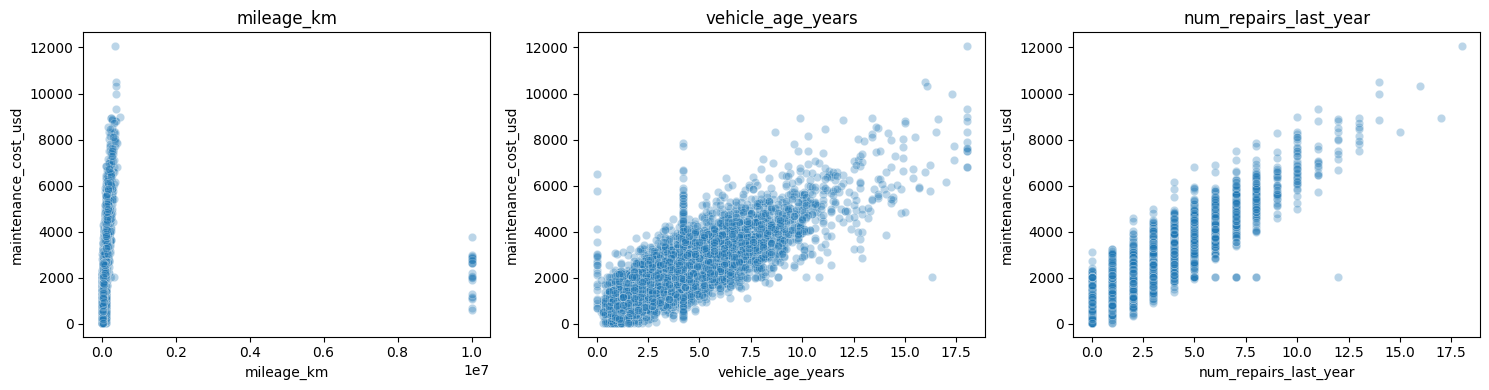

In [275]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['mileage_km','vehicle_age_years','num_repairs_last_year']):
    sns.scatterplot(data=df, x=col, y='maintenance_cost_usd', alpha=0.3, ax=ax)
    ax.set_title(col)
plt.tight_layout()

In [300]:
y = df['maintenance_cost_usd']
X = df[['mileage_km', 'vehicle_age_years', 'num_repairs_last_year','engine_hours']]

In [301]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [302]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [304]:
pred = model.predict(X_test)
pred

array([1384.9718661 , 2811.62480171, 2422.79827757, ..., 2669.23034955,
       1330.44088482, 3944.31135898])

In [306]:
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Squared Error: 189954.59933280307
Root Mean Squared Error: 435.83781310575046
R-squared: 0.9000627754203993


In [307]:
pd.Series(model.coef_, index=X_train.columns).sort_values(ascending=False)

,0
num_repairs_last_year,389.641947
vehicle_age_years,114.932079
engine_hours,0.179994
mileage_km,0.002059


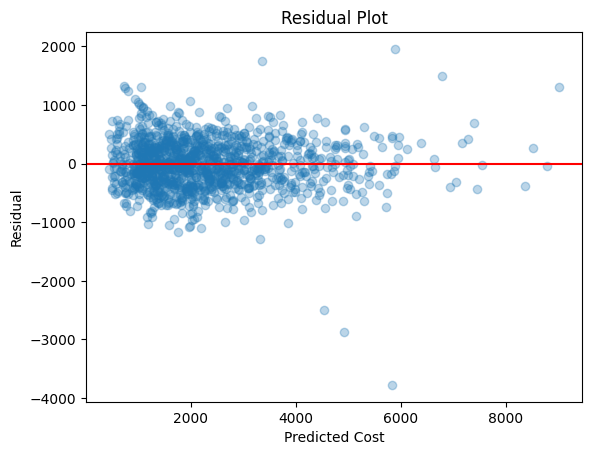

In [309]:
residuals = y_test - pred
plt.scatter(pred, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('Predicted Cost')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

In [312]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print('R² per fold:', cv_scores.round(4))
print('Mean R²:', cv_scores.mean().round(4))
print('Std R²:', cv_scores.std().round(4))

R² per fold: [0.8955 0.9103 0.9099 0.9067 0.8838]
Mean R²: 0.9012
Std R²: 0.0102


In [313]:
df['breakdown_next_30_days'].value_counts(normalize=True)

,proportion
breakdown_next_30_days,
True,0.670333
False,0.329667


In [314]:
df.head()

,vehicle_id,vehicle_type,manufacturer,region,fuel_type,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,tire_condition,maintenance_cost_usd,breakdown_next_30_days,days_since_last_service,service_date_missing
0,VH-13687,Van,Hyundai,Central,Diesel,2012-12-04,2025-02-20,12.5,219266.0,4763.0,16.5,10.0,4.000000,Good,7088.55,True,288.0,False
1,VH-13098,Truck,Toyota,Central,Gasoline,2015-08-16,2025-01-22,9.8,115261.0,2737.0,25.9,2.0,2.600000,Good,3745.02,False,317.0,False
2,VH-13739,Sedan,Hyundai,West,Diesel,2018-02-14,2025-02-20,7.3,149791.0,3447.0,12.3,3.0,2.100000,Good,3011.11,False,288.0,False
3,VH-13366,Van,Nissan,Central,Hybrid,2024-12-01,2025-07-04,0.5,4075.0,200.0,14.1,0.0,4.111097,Good,673.45,True,154.0,False
4,VH-15413,Truck,Mercedes,South,Diesel,2023-06-02,2024-09-24,2.0,16074.0,432.0,25.1,3.0,3.100000,Good,2086.91,True,437.0,False


In [315]:
y = df['breakdown_next_30_days']
X = df[['vehicle_age_years','mileage_km','engine_hours','avg_fuel_consumption_l_100km','num_repairs_last_year','driver_rating','tire_condition', 'days_since_last_service']]

In [316]:
X.head()

,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,tire_condition,days_since_last_service
0,12.5,219266.0,4763.0,16.5,10.0,4.000000,Good,288.0
1,9.8,115261.0,2737.0,25.9,2.0,2.600000,Good,317.0
2,7.3,149791.0,3447.0,12.3,3.0,2.100000,Good,288.0
3,0.5,4075.0,200.0,14.1,0.0,4.111097,Good,154.0
4,2.0,16074.0,432.0,25.1,3.0,3.100000,Good,437.0


In [317]:
X = pd.get_dummies(X, columns=['tire_condition'])

In [318]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [323]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, random_state=42)

In [324]:
pred = model.predict(X_test)
pred

array([ True,  True,  True, ...,  True,  True,  True])

In [326]:
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.7496038034865293
Recall: 0.5883084577114428
F1 Score: 0.659233449477352


In [327]:
probs = model.predict_proba(X_test)

In [328]:
probs

array([[0.20983495, 0.79016505],
       [0.16792805, 0.83207195],
       [0.40577769, 0.59422231],
       ...,
       [0.45264496, 0.54735504],
       [0.48234104, 0.51765896],
       [0.24988859, 0.75011141]])

In [332]:
tire_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
df['tire_condition'] = df['tire_condition'].map(tire_map)

<Axes: >

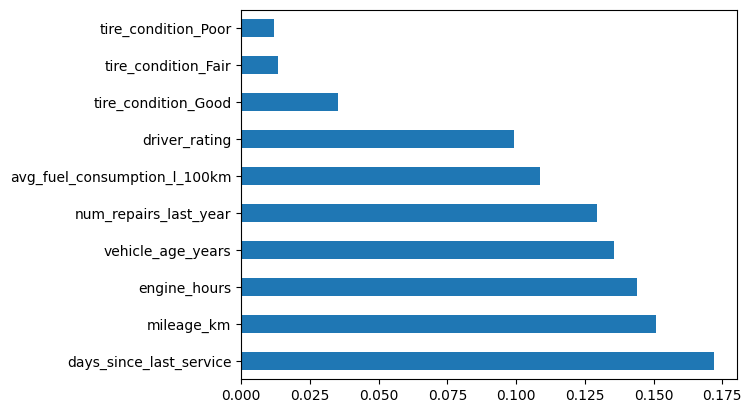

In [337]:
pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).plot.barh()

In [338]:
df.head()

,vehicle_id,vehicle_type,manufacturer,region,fuel_type,purchase_date,last_service_date,vehicle_age_years,mileage_km,engine_hours,avg_fuel_consumption_l_100km,num_repairs_last_year,driver_rating,tire_condition,maintenance_cost_usd,breakdown_next_30_days,days_since_last_service,service_date_missing
0,VH-13687,Van,Hyundai,Central,Diesel,2012-12-04,2025-02-20,12.5,219266.0,4763.0,16.5,10.0,4.000000,2,7088.55,True,288.0,False
1,VH-13098,Truck,Toyota,Central,Gasoline,2015-08-16,2025-01-22,9.8,115261.0,2737.0,25.9,2.0,2.600000,2,3745.02,False,317.0,False
2,VH-13739,Sedan,Hyundai,West,Diesel,2018-02-14,2025-02-20,7.3,149791.0,3447.0,12.3,3.0,2.100000,2,3011.11,False,288.0,False
3,VH-13366,Van,Nissan,Central,Hybrid,2024-12-01,2025-07-04,0.5,4075.0,200.0,14.1,0.0,4.111097,2,673.45,True,154.0,False
4,VH-15413,Truck,Mercedes,South,Diesel,2023-06-02,2024-09-24,2.0,16074.0,432.0,25.1,3.0,3.100000,2,2086.91,True,437.0,False


In [335]:
print(y_test.dtype)

bool
